In [ ]:
import pandas as pd
import pyarrow
df = pd.read_parquet("/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/nucleus_boundaries.parquet", engine="pyarrow")

import tifffile

fullres_img_tiff = tifffile.imread(
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/morphology_focus.ome.tif", is_ome=False, level=0)

In [ ]:
import cv2
import numpy as np

def extract_polygon_region(image, coords):
    """
    image: Input image as a NumPy array (e.g., from cv2.imread or PIL.Image)
    coords: List of (x, y) tuples defining the polygon (e.g., [(x1,y1), (x2,y2), ..., (xn,yn)])
    """
    # Step 1: Create a mask of the same size as the image
    mask = np.zeros(image.shape[:2], dtype=np.uint8)  # single channel

    # Step 2: Convert coords to numpy array of shape (n,1,2)
    polygon = np.array([coords], dtype=np.int32)

    # Step 3: Fill the polygon area with white (255)
    cv2.fillPoly(mask, polygon, 255)

    # Step 4: Bitwise-and mask with image
    masked = cv2.bitwise_and(image, image, mask=mask)

    # Step 5: Crop to bounding box of polygon (optional but cleaner)
    x, y, w, h = cv2.boundingRect(polygon)
    cropped = masked[y:y+h, x:x+w]

    return cropped

In [19]:
# Decode each cell_id from bytes to string
cell_ids = [cell_id.decode('UTF-8') for cell_id in df["cell_id"].unique()]
# Print the decoded cell_ids
print(cell_ids)

['aaadnakl-1', 'aaaeaoem-1', 'aaaebjlp-1', 'aaahenla-1', 'aaahgemb-1', 'aaaimdeo-1', 'aaajokmn-1', 'aaakalce-1', 'aaakembk-1', 'aaakjjhb-1', 'aaalnmni-1', 'aaamgbhi-1', 'aaanpfga-1', 'aaaofpgn-1', 'aaaoheoo-1', 'aaapcahd-1', 'aaapnplb-1', 'aabbaofa-1', 'aabbpohh-1', 'aabcmmgi-1', 'aabeiefk-1', 'aabfhkoc-1', 'aabgjgld-1', 'aabgpfne-1', 'aabhgocl-1', 'aabidmgb-1', 'aabikkgb-1', 'aabjcbjb-1', 'aabjllaj-1', 'aablmnjn-1', 'aabmhnfg-1', 'aabphpao-1', 'aabpifgj-1', 'aacadflp-1', 'aacajcnd-1', 'aacbfkfa-1', 'aacdijlg-1', 'aacdkbhm-1', 'aacdkgma-1', 'aacfpibg-1', 'aacglaam-1', 'aachaadp-1', 'aaclmejf-1', 'aacmpljm-1', 'aacnfefg-1', 'aacodmkj-1', 'aacpcdcb-1', 'aadcfcka-1', 'aaddfbpm-1', 'aadepleh-1', 'aadfacck-1', 'aadgakhf-1', 'aadgfbec-1', 'aadifojh-1', 'aadlnehg-1', 'aadmkhdc-1', 'aadnjmcc-1', 'aadoiokp-1', 'aadpddko-1', 'aadpenja-1', 'aaeaoaek-1', 'aaedndja-1', 'aaeecklh-1', 'aaeepaje-1', 'aaeepehh-1', 'aaefilkc-1', 'aaegjmon-1', 'aaeicfcl-1', 'aaejbbab-1', 'aaekongk-1', 'aaekpeio-1', 'aaem

In [22]:
def extract_cell_coordinates(df, scale_factor=0.2125):
    """
    Extract x and y coordinates for all unique cell_ids.

    Parameters:
    df (pd.DataFrame): DataFrame containing cell data with 'cell_id', 'vertex_x', and 'vertex_y' columns.
    scale_factor (float): Scaling factor for coordinates.

    Returns:
    dict: A dictionary with cell_ids as keys and lists of (x, y) tuples as values.
    """
    cell_ids = [cell_id.decode('UTF-8') for cell_id in df["cell_id"].unique()]
    cell_coords = {}
    for i, cell_id in enumerate(cell_ids):
        cell_df = df[df["cell_id"] == cell_id]
        x_coords = np.ceil(cell_df["vertex_x"].values / scale_factor)
        y_coords = np.ceil(cell_df["vertex_y"].values / scale_factor)
        coords = list(zip(x_coords, y_coords))
        cell_coords[cell_id] = coords
    return cell_coords

In [21]:
# add padding to the images to make them 100 x 100 without resizing
def add_padding(image, target_size=(100, 100)):
    """
    Add padding to the image to make it the target size without resizing.
    """
    h, w = image.shape[:2]
    target_h, target_w = target_size

    # Create a new blank image with the target size
    padded_image = np.zeros((target_h, target_w), dtype=image.dtype)

    # Calculate padding offsets
    y_offset = (target_h - h) // 2
    x_offset = (target_w - w) // 2

    # Place the original image in the center of the padded image
    padded_image[y_offset:y_offset + h, x_offset:x_offset + w] = image

    return padded_image

In [1]:
import os
import gc

directories = ["/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/",
                    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_5_7_months_outs/",
                    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_17_9_months_outs/",
                    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_2_5_months_outs/",
                    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_5_7_months_outs/",
                    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_13_4_months_outs/"]

# read nucleus_boundaries.parquet and morphology_focus.ome.tif for each directory
dfs = []
tiffs = []
for directory in directories:
    sample_name = directory.split("_V1_FFPE_")[1].split("_months_outs")[0]

    df = pd.read_parquet(os.path.join(directory, "nucleus_boundaries.parquet"), engine="pyarrow")
    dfs.append(df)
    tiff = tifffile.imread(os.path.join(directory, "morphology_focus.ome.tif"), is_ome=False, level=0)
    tiffs.append(tiff)
    print(f"Loaded {directory} with shape {tiff.shape} and {df.shape[0]} rows")

    # extract cell coordinates
    cell_coords = extract_cell_coordinates(df)
    # extract cell images
    cell_images = {}
    for cell_id, coords in cell_coords.items():
        cell_img = extract_polygon_region(tiff, coords)
        # cell_img_padded = add_padding(cell_img)
        cell_images[cell_id] = cell_img

    # save cell_images to a file as .hdf5
    import h5py
    output_dir = "cell_images"
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, sample_name + "_cell_images.hdf5")
    with h5py.File(output_file, "w") as f:
        for cell_id, cell_img in cell_images.items():
            cell_img = np.clip(cell_img, 0, 255).astype(np.uint8)
            f.create_dataset(str(cell_id), data=cell_img)
            del cell_img
            gc.collect()
    

NameError: name 'pd' is not defined

TypeError: Image data of dtype |S32 cannot be converted to float

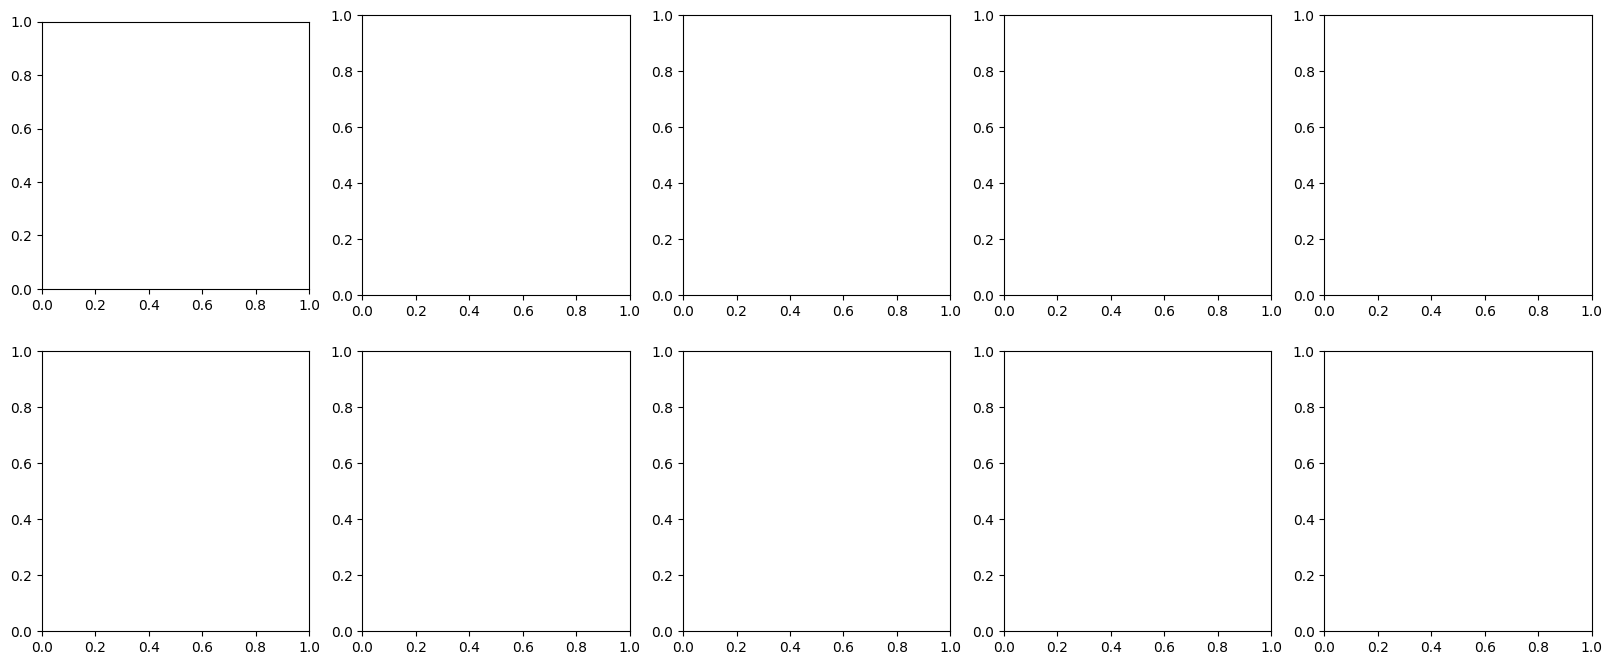

In [8]:
import h5py
import matplotlib.pyplot as plt
import random
import os

with h5py.File("/home/anagupta/luna/preprocess/cell_images/TgCRND8_2_5_cell_images.hdf5", "r") as f:
    cell_ids = list(f.keys())
    random_cell_ids = cell_ids
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, cell_id in zip(axes.flatten(), random_cell_ids):
        cell_img = f[cell_id][:]
        ax.imshow(cell_img, cmap="gray")
        ax.set_title(f"Cell ID: {cell_id}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# import matplotlib.pyplot as plt
# import random
# import h5py
# import numpy as np
# import os
# import cv2

# def plot_random_cells(hdf5_file, num_cells=5):
#     with h5py.File(hdf5_file, "r") as f:
#         images = f["images"][:]
#         cell_ids = f["cell_ids"][:]

#         print(f"Number of images: {len(images)}")
#         print(f"Number of cell IDs: {len(cell_ids)}")

#         # Randomly select cell indices
#         random_indices = random.sample(range(len(images)), num_cells)

#         # Create a directory to save the images
#         output_dir = "random_cell_images"
#         os.makedirs(output_dir, exist_ok=True)

#         for i, idx in enumerate(random_indices):
#             img = images[idx]
#             cell_id = cell_ids[idx]

#             # Save the image
#             output_path = os.path.join(output_dir, f"{cell_id}.png")
#             cv2.imwrite(output_path, img)
#             print(f"Saved {output_path}")
#             # Display the image
#             plt.imshow(img, cmap='gray')
#             plt.title(f"Cell ID: {cell_id}")
#             plt.axis('off')
#             plt.show()

# # Example usage
# hdf5_file = "/home/anagupta/luna/preprocess/cell_images/TgCRND8_2_5_cell_images.hdf5"
# plot_random_cells(hdf5_file, num_cells=5)

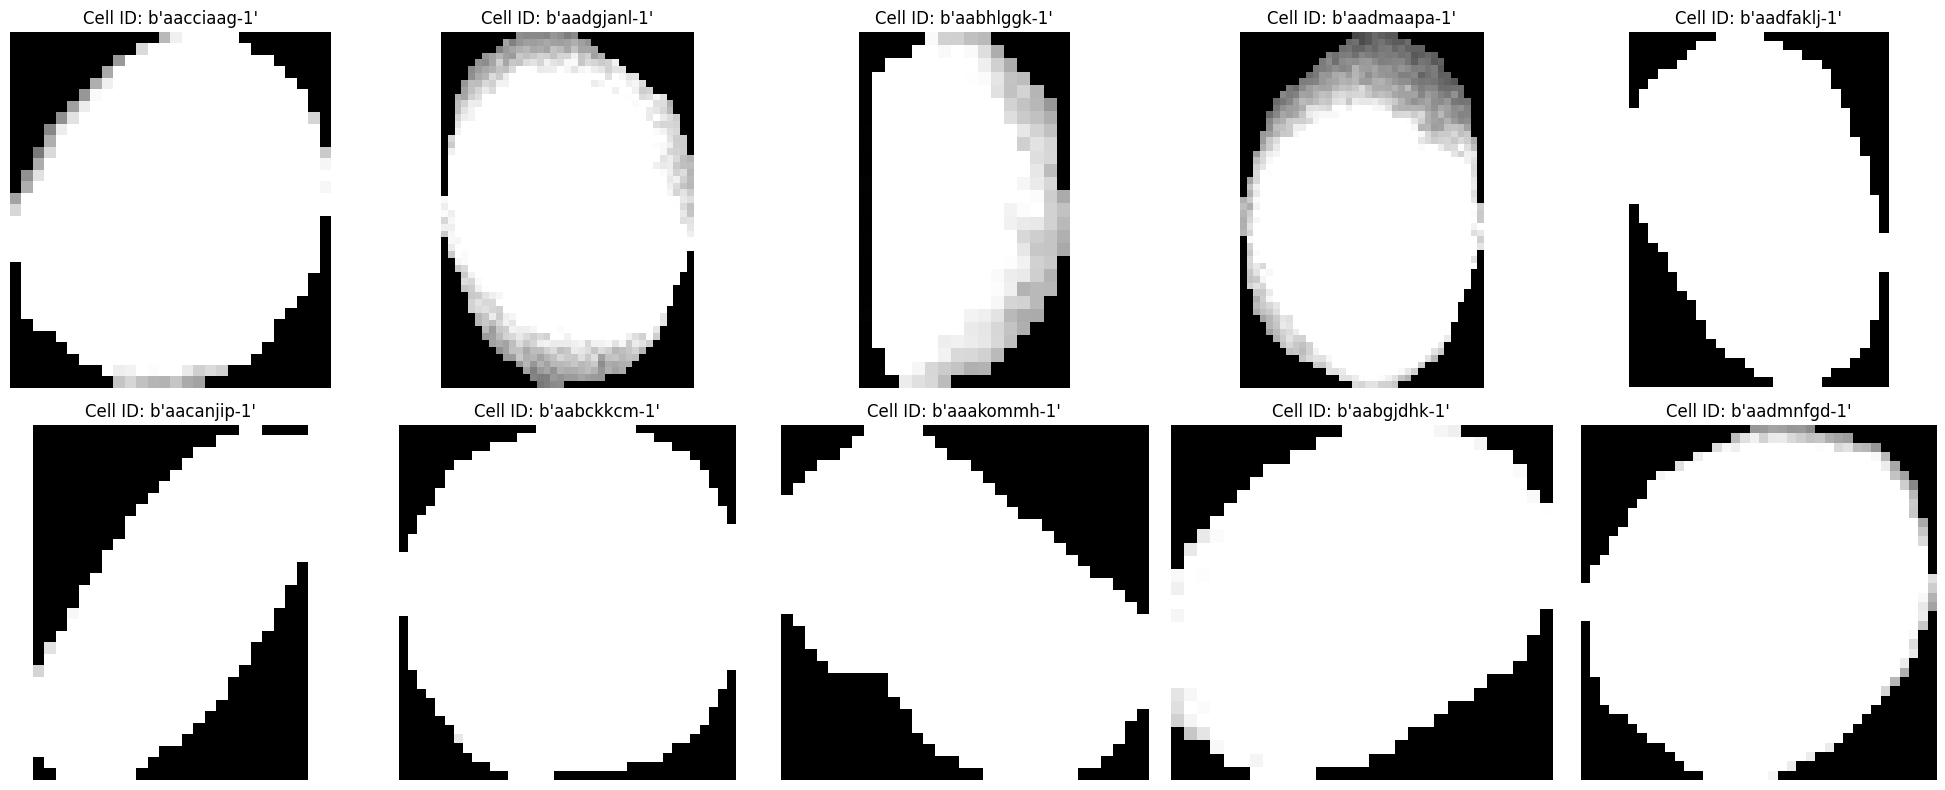

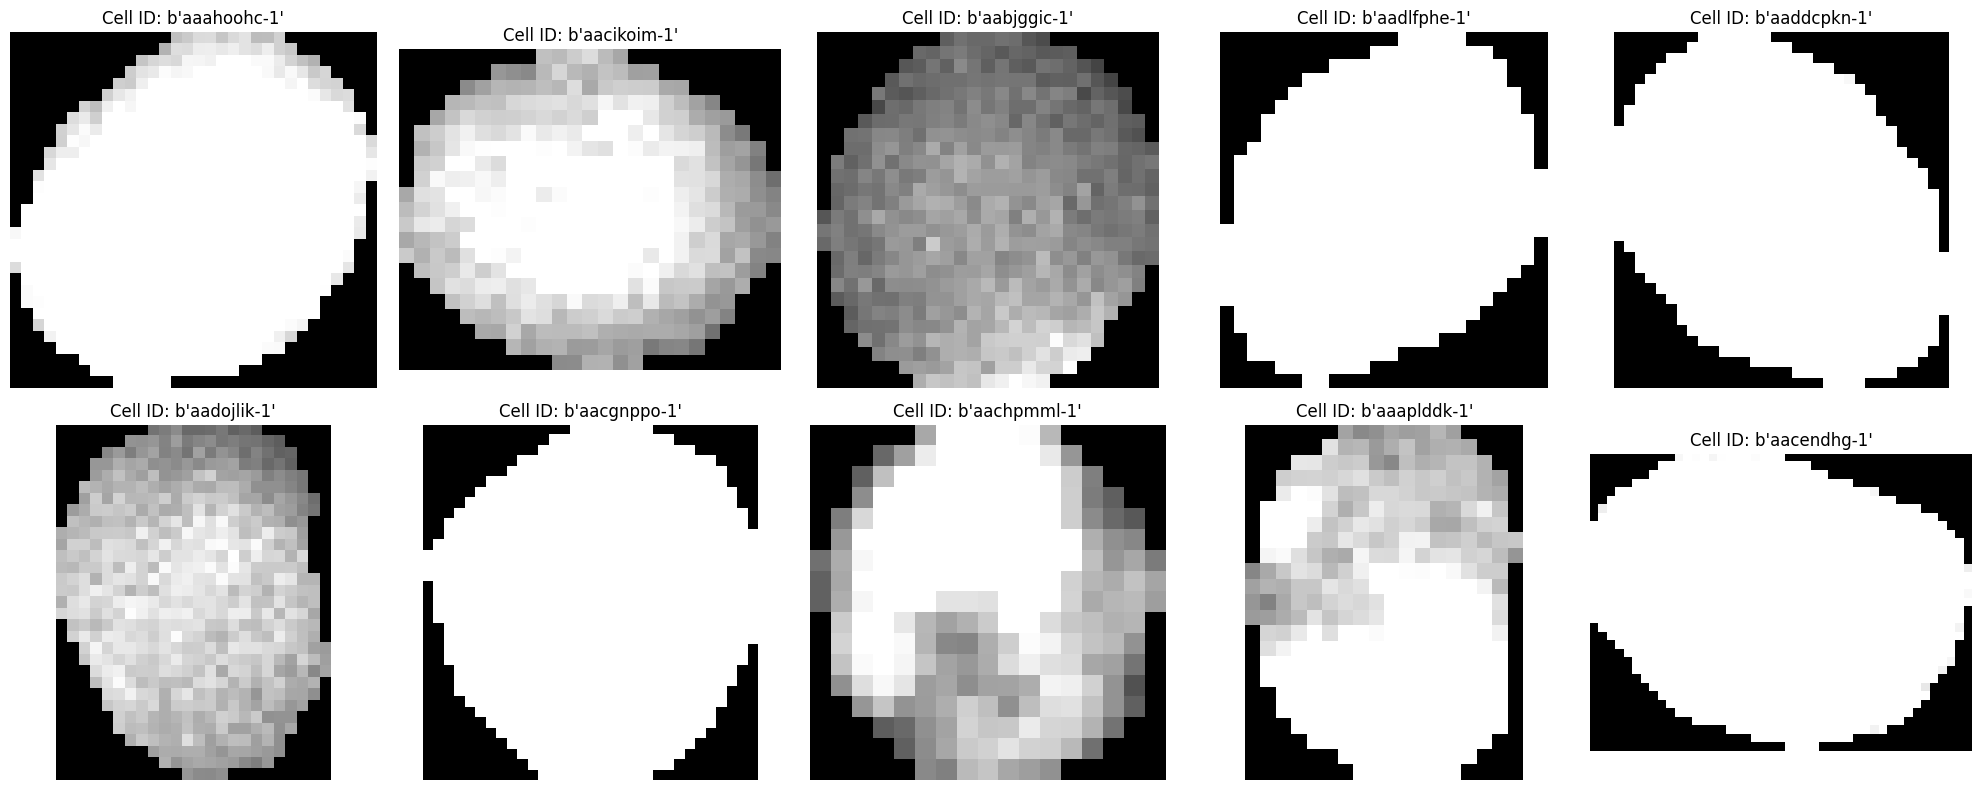

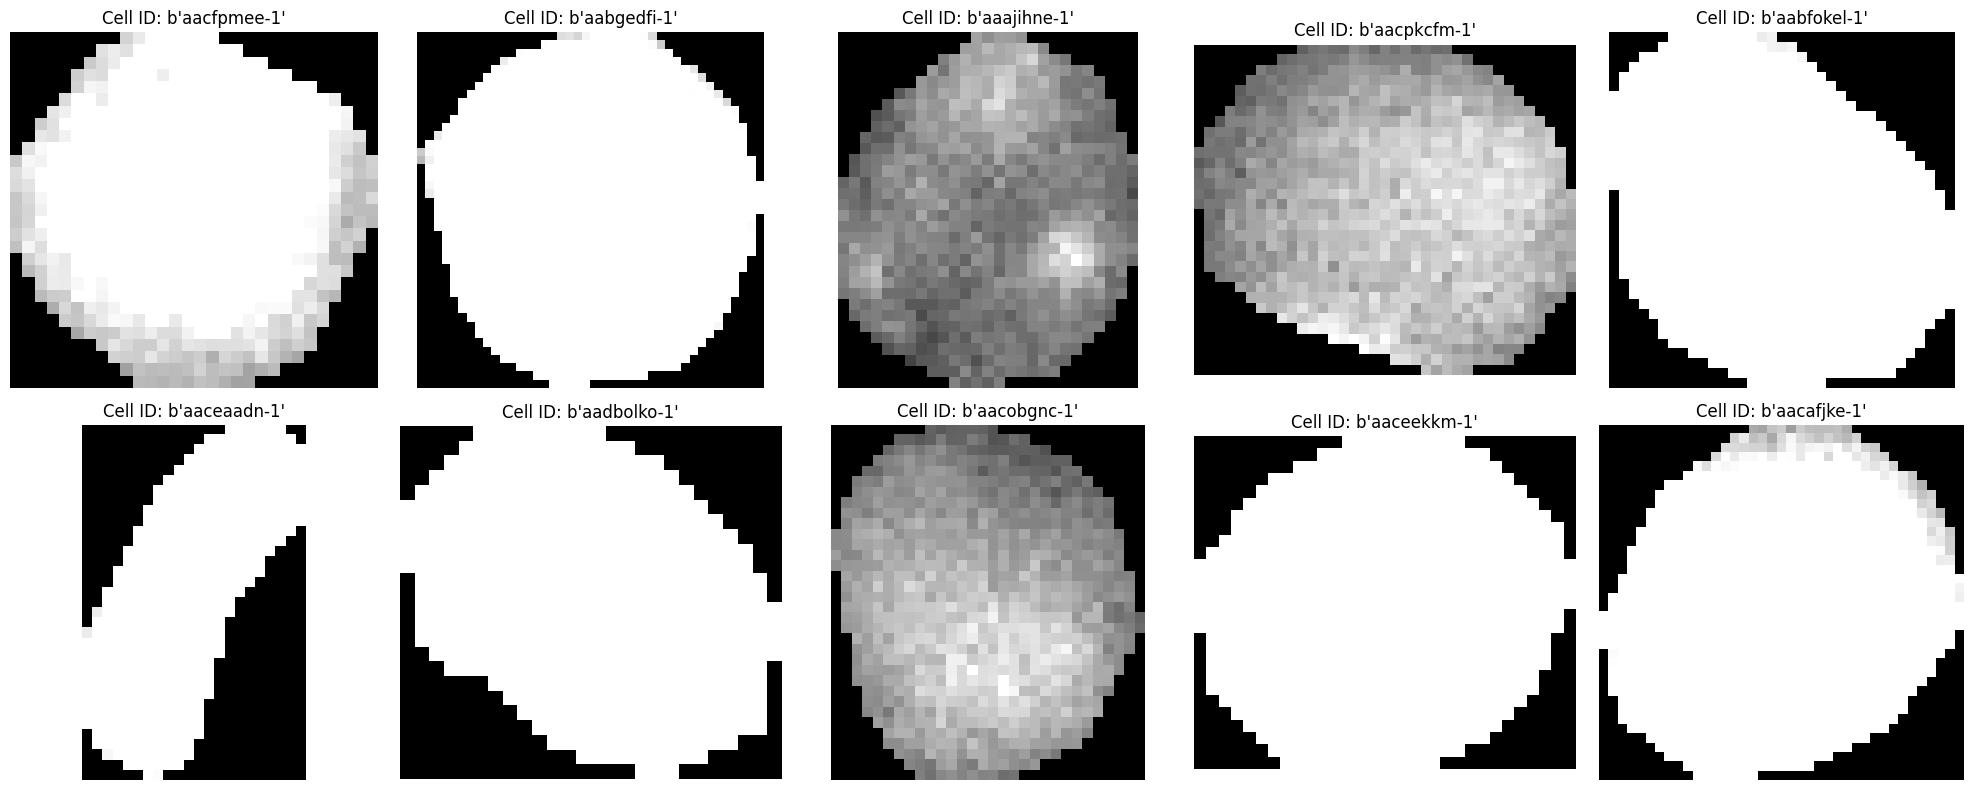

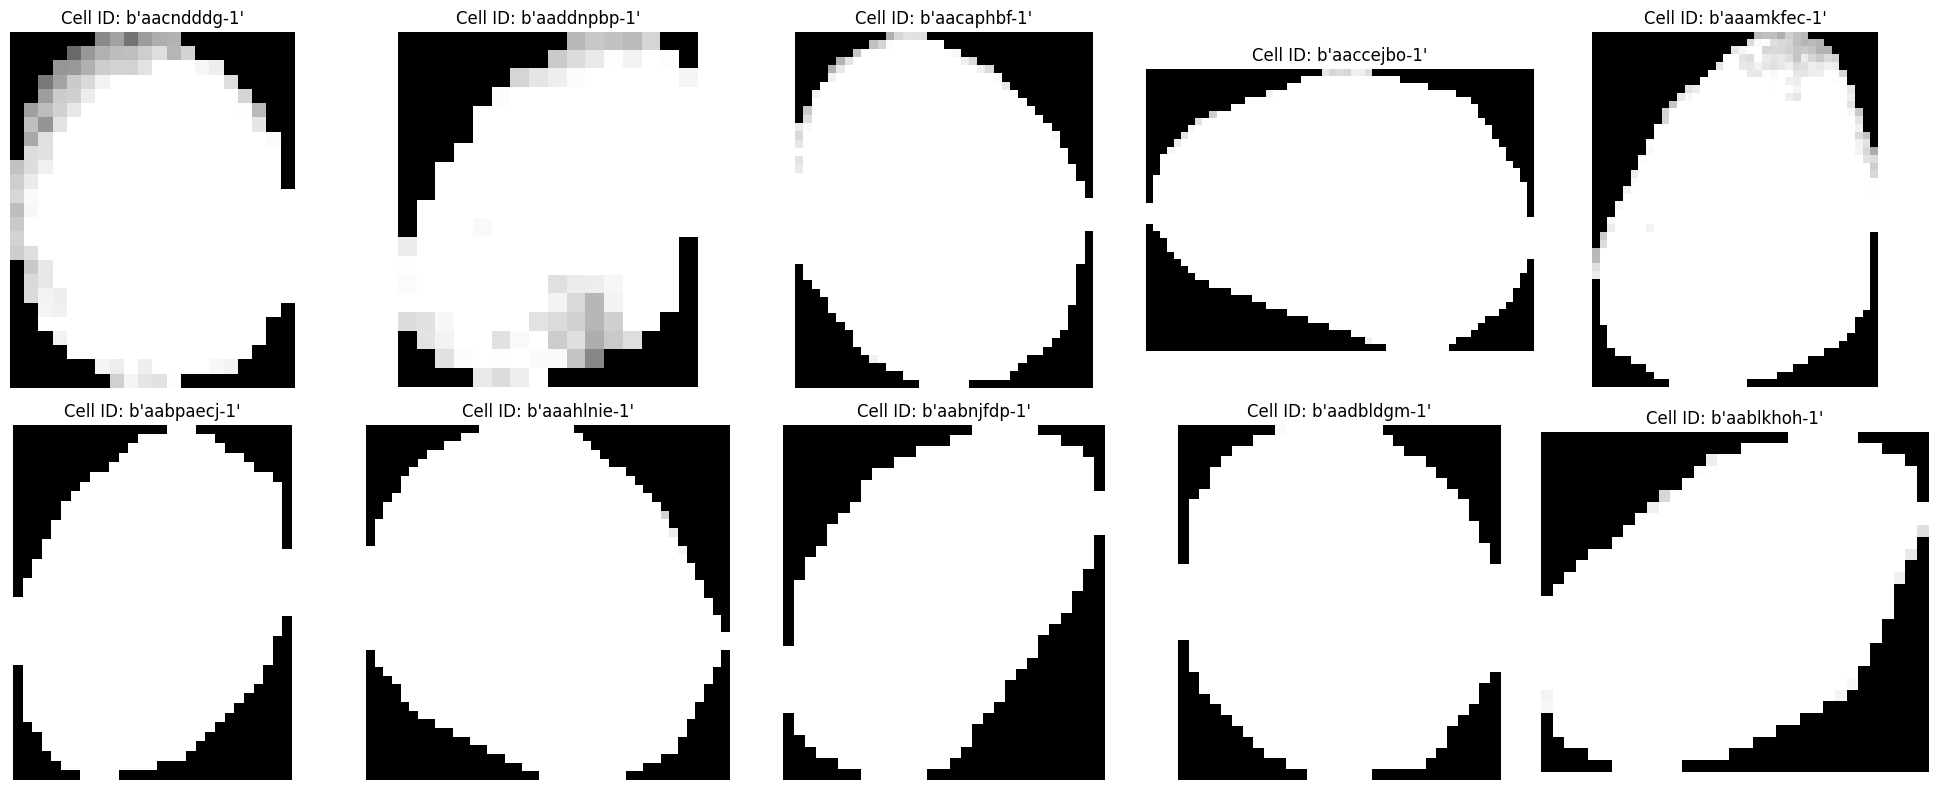

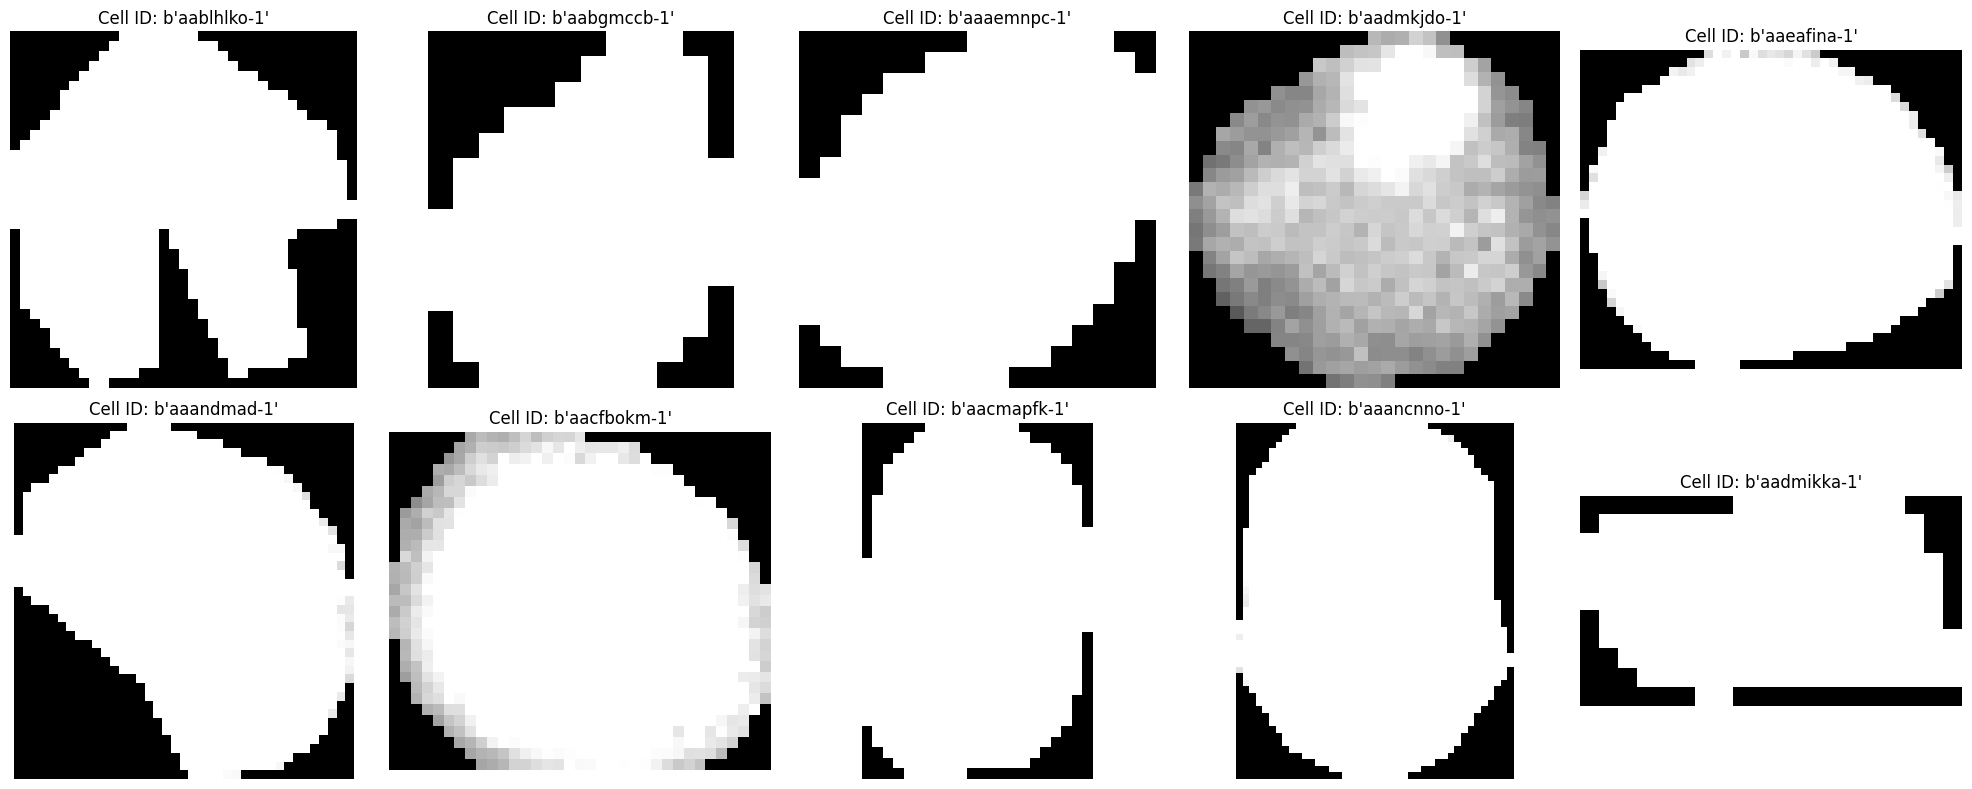

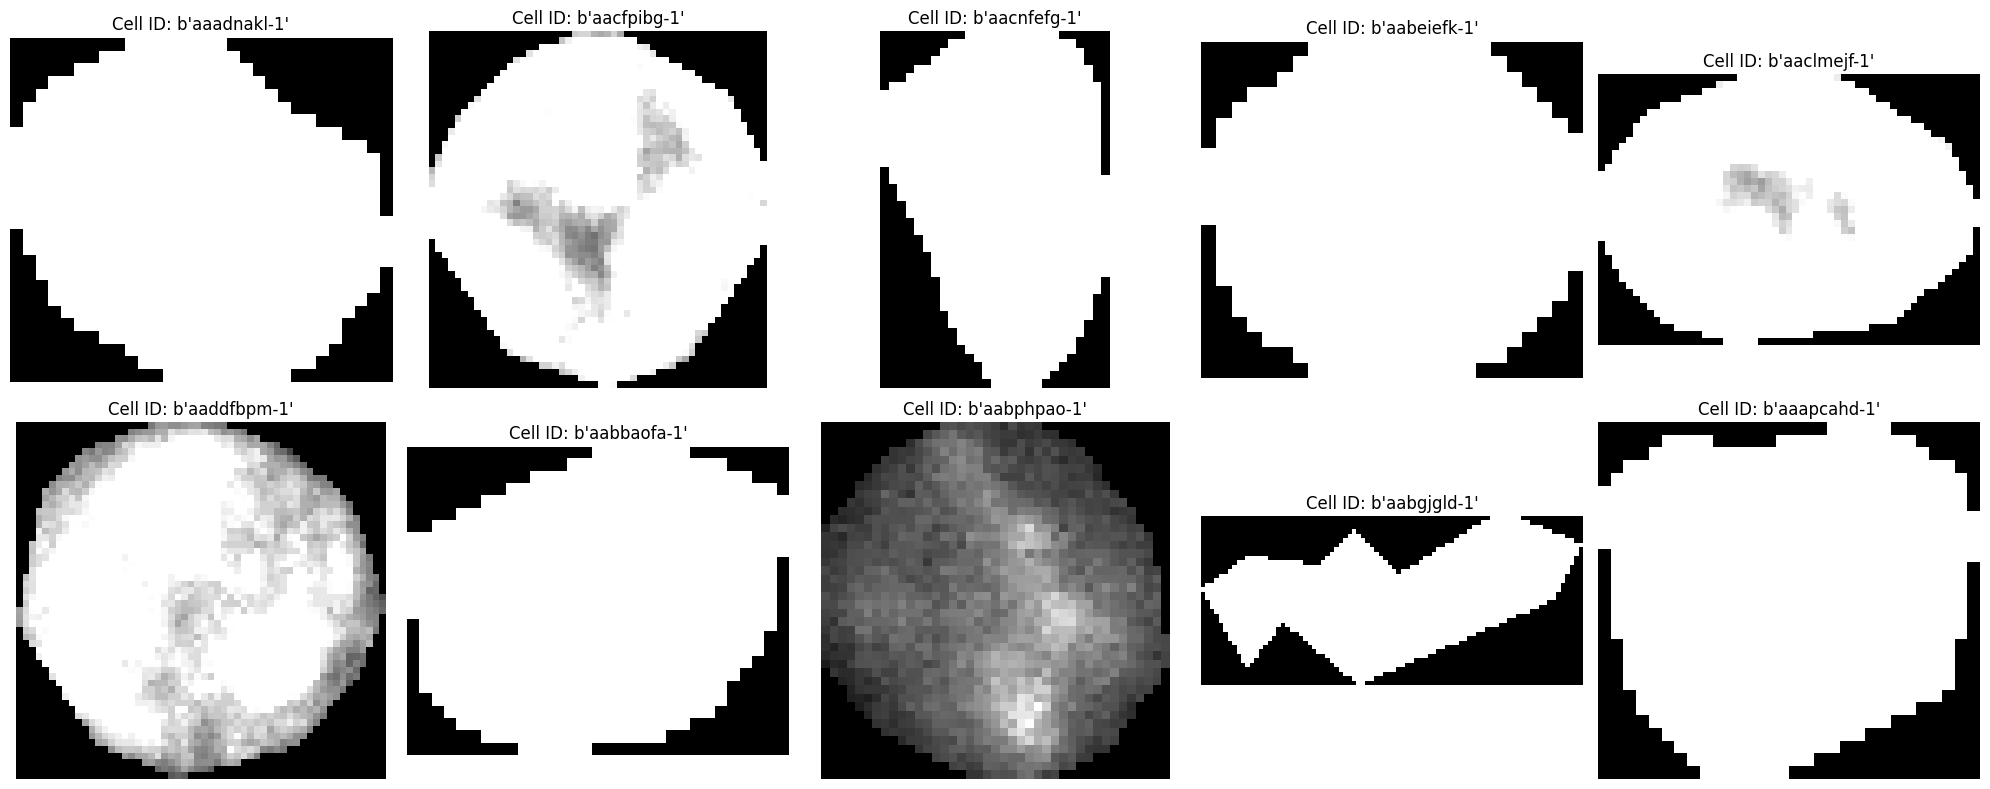

In [7]:
# open the hdf5 file and plot randomly 10 cell images from each sample
import h5py
import matplotlib.pyplot as plt
import random
import os
output_dir = "cell_images"
sample_names = [directory.split("_V1_FFPE_")[1].split("_months_outs")[0] for directory in directories]
for sample_name in sample_names:
    output_file = os.path.join(output_dir, sample_name + "_cell_images.hdf5")
    with h5py.File(output_file, "r") as f:
        cell_ids = list(f.keys())
        random_cell_ids = random.sample(cell_ids, 10)
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        for ax, cell_id in zip(axes.flatten(), random_cell_ids):
            cell_img = f[cell_id][:]
            ax.imshow(cell_img, cmap="gray")
            ax.set_title(f"Cell ID: {cell_id}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

In [2]:
# %%
import pandas as pd
df = pd.read_parquet("/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/nucleus_boundaries.parquet")

import tifffile

# fullres_img_tiff = tifffile.imread(
#     "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/morphology_focus.ome.tif", is_ome=False, level=0)

output_dir = "/home/anagupta/luna/preprocess/cell_images"

# %%
import cv2
import numpy as np


In [3]:
# %%
def extract_cell_boundary_vertices(df, scale_factor=0.2125):
    """
    Extract x and y coordinates for all unique cell_ids.

    Parameters:
    df (pd.DataFrame): DataFrame containing cell data with 'cell_id', 'vertex_x', and 'vertex_y' columns.
    scale_factor (float): Scaling factor for coordinates.

    Returns:
    dict: A dictionary with cell_ids as keys and lists of (x, y) tuples as values.
    """
    cell_ids = df["cell_id"].unique()
    cell_coords = {}
    for i, cell_id in enumerate(cell_ids):
        if i >1:
            break
        if i % 1000 == 0:
            print(f"Processed {i} cell_boundary_vertices ...")
        cell_df = df[df["cell_id"] == cell_id]
        x_coords = np.ceil(cell_df["vertex_x"].values / scale_factor)
        y_coords = np.ceil(cell_df["vertex_y"].values / scale_factor)
        coords = list(zip(x_coords, y_coords))
        cell_coords[cell_id] = coords
    return cell_coords

In [ ]:
#%%
def extract_cell_image_from_boundary_vertices(image, coords):
    """
    image: Input image as a NumPy array (e.g., from cv2.imread or PIL.Image)
    coords: List of (x, y) tuples defining the vertices of the cell boundary polygon (e.g., [(x1,y1), (x2,y2), ..., (xn,yn)])
    """
    if not coords:
        raise ValueError("Coordinates list is empty. Cannot extract cell image.")

    # Step 1: Create a mask of the same size as the image
    mask = np.zeros(image.shape[:2], dtype=np.uint8)  # single channel

    # Step 2: Convert coords to numpy array of shape (n,1,2)
    polygon = np.array([coords], dtype=np.int32)
    # Step 3: Fill the polygon area with white (255)
    cv2.fillPoly(mask, polygon, 255)

    # Step 4: Bitwise-and mask with image
    masked = cv2.bitwise_and(image, image, mask=mask)

    # Step 5: Crop to bounding box of polygon (optional but cleaner)
    x, y, w, h = cv2.boundingRect(polygon)
    if w == 0 or h == 0:
        raise ValueError(f"Bounding box has zero width or height: (x={x}, y={y}, w={w}, h={h}). Check the input coordinates.")
    cropped = masked[y:y+h, x:x+w]

    return cropped

In [ ]:
# add padding to the images to make them target size without resizing
def add_padding(image, target_size=(128, 128)):
    h, w = image.shape[:2]
    target_h, target_w = target_size

    # Create a new blank image with the target size
    padded_image = np.zeros((target_h, target_w), dtype=image.dtype)

    # Calculate padding offsets
    y_offset = (target_h - h) // 2
    x_offset = (target_w - w) // 2

    # Place the original image in the center of the padded image
    padded_image[y_offset:y_offset + h, x_offset:x_offset + w] = image

    return padded_image

In [9]:
import tarfile
import io

directories = [
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_5_7_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_17_9_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_2_5_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_5_7_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_13_4_months_outs/"
    ]

# read nucleus_boundaries.parquet and morphology_focus.ome.tif for each directory
for directory in directories:
    sample_name = directory.split("_V1_FFPE_")[1].split("_months_outs")[0]

    df = pd.read_parquet(os.path.join(directory, "nucleus_boundaries.parquet"), engine="pyarrow")
    tiff = tifffile.imread(os.path.join(directory, "morphology_focus.ome.tif"), is_ome=False, level=0)
    print(f"Loaded {directory} with shape {tiff.shape} and {df.shape[0]} rows")
    cell_boundary_vertices = extract_cell_boundary_vertices(df)

    # Create a tar file to store all cell images
    tar_file_path = os.path.join(output_dir, f"{sample_name}_cell_images.tar")
    with tarfile.open(tar_file_path, "w") as tar:
        for i, (cell_id, cell_boundary_vertices) in enumerate(cell_boundary_vertices.items()):
            if i > 1000:
                break
            if i % 1000 == 0:
                print(f"Processed {i} cell_images...")
            try:
                # Extract the polygon region from the image
                cell_img = extract_cell_image_from_boundary_vertices(tiff, cell_boundary_vertices)
                print(f"Extracted cell image for cell_id {cell_id} with shape {cell_img.shape}")
                
                # Add padding to the image
                cell_img_padded = add_padding(cell_img)
                
                # Save the image to an in-memory buffer
                img_buffer = io.BytesIO()
                np.save(img_buffer, cell_img_padded)
                img_buffer.seek(0)
                
                # Add the image to the tar file
                tar_info = tarfile.TarInfo(name=f"{cell_id.decode('utf-8')}.npy")
                tar_info.size = img_buffer.getbuffer().nbytes
                tar.addfile(tarinfo=tar_info, fileobj=img_buffer)
                
            except Exception as e:
                print(f"Error processing cell_id {cell_id} in {sample_name}: {e}. Skipping.")
                continue

    print(f"Finished saving all cells for {sample_name} to {tar_file_path}")


Loaded /scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/ with shape (20739, 28492) and 700756 rows
Processed 0 cell_boundary_vertices ...
Processed 0 cell_images...
Extracted cell image for cell_id b'aaabfoap-1' with shape (34, 27)
Extracted cell image for cell_id b'aaabonpk-1' with shape (53, 24)
Finished saving all cells for TgCRND8_2_5 to /home/anagupta/luna/preprocess/cell_images/TgCRND8_2_5_cell_images.tar
Loaded /scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_5_7_months_outs/ with shape (20741, 28491) and 762715 rows
Processed 0 cell_boundary_vertices ...
Processed 0 cell_images...
Extracted cell image for cell_id b'aaabaohn-1' with shape (40, 37)
Extracted cell image for cell_id b'aaabocno-1' with shape (27, 28)
Finished saving all cells for TgCRND8_5_7 to /home/anagupta/luna/preprocess/cell_images/TgCRND8_5_7_cell_images.tar
Loaded /scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_17_9_months_outs/ with shape (24864, 31348) and 809351 rows
Processed 

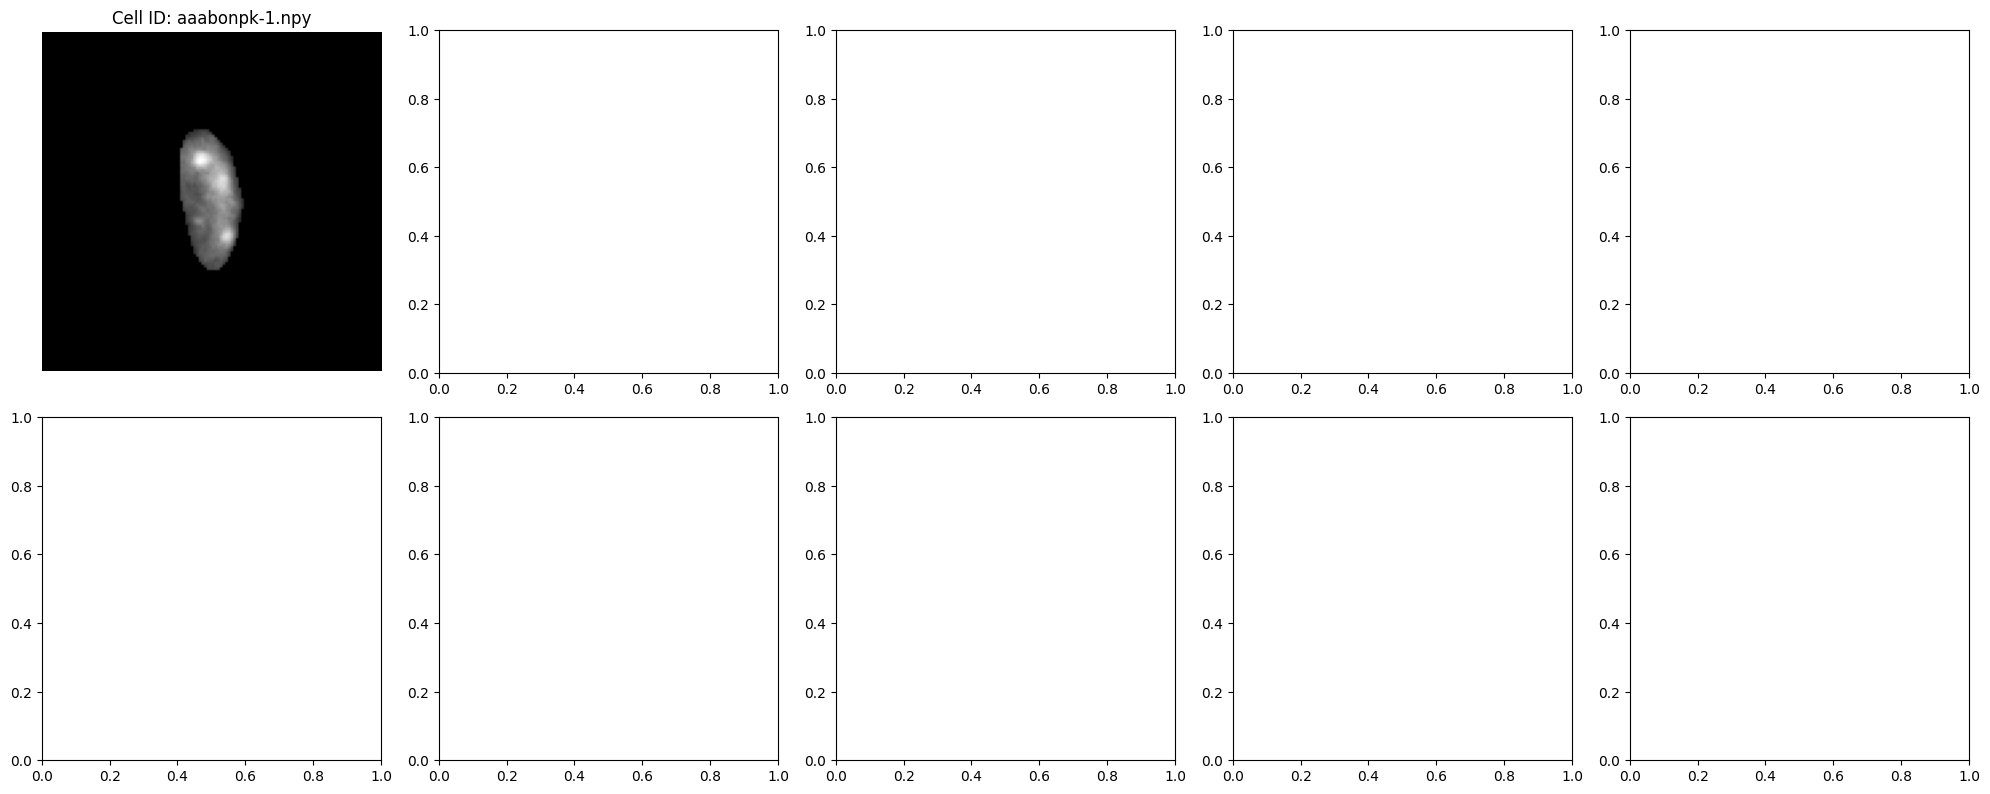

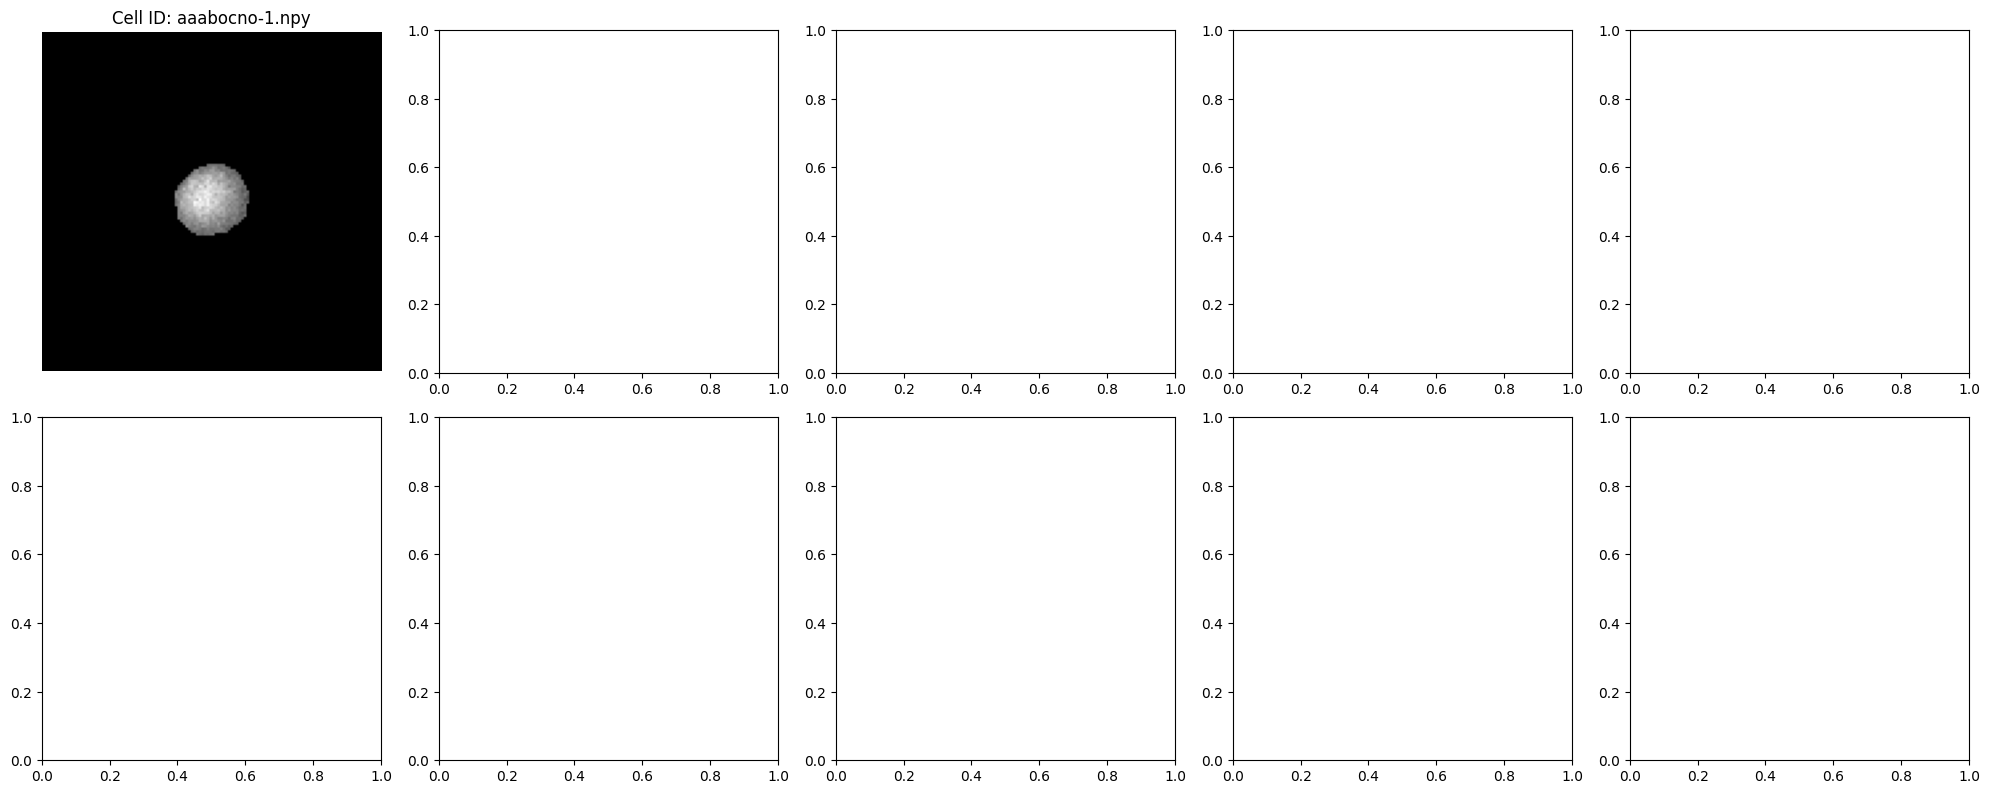

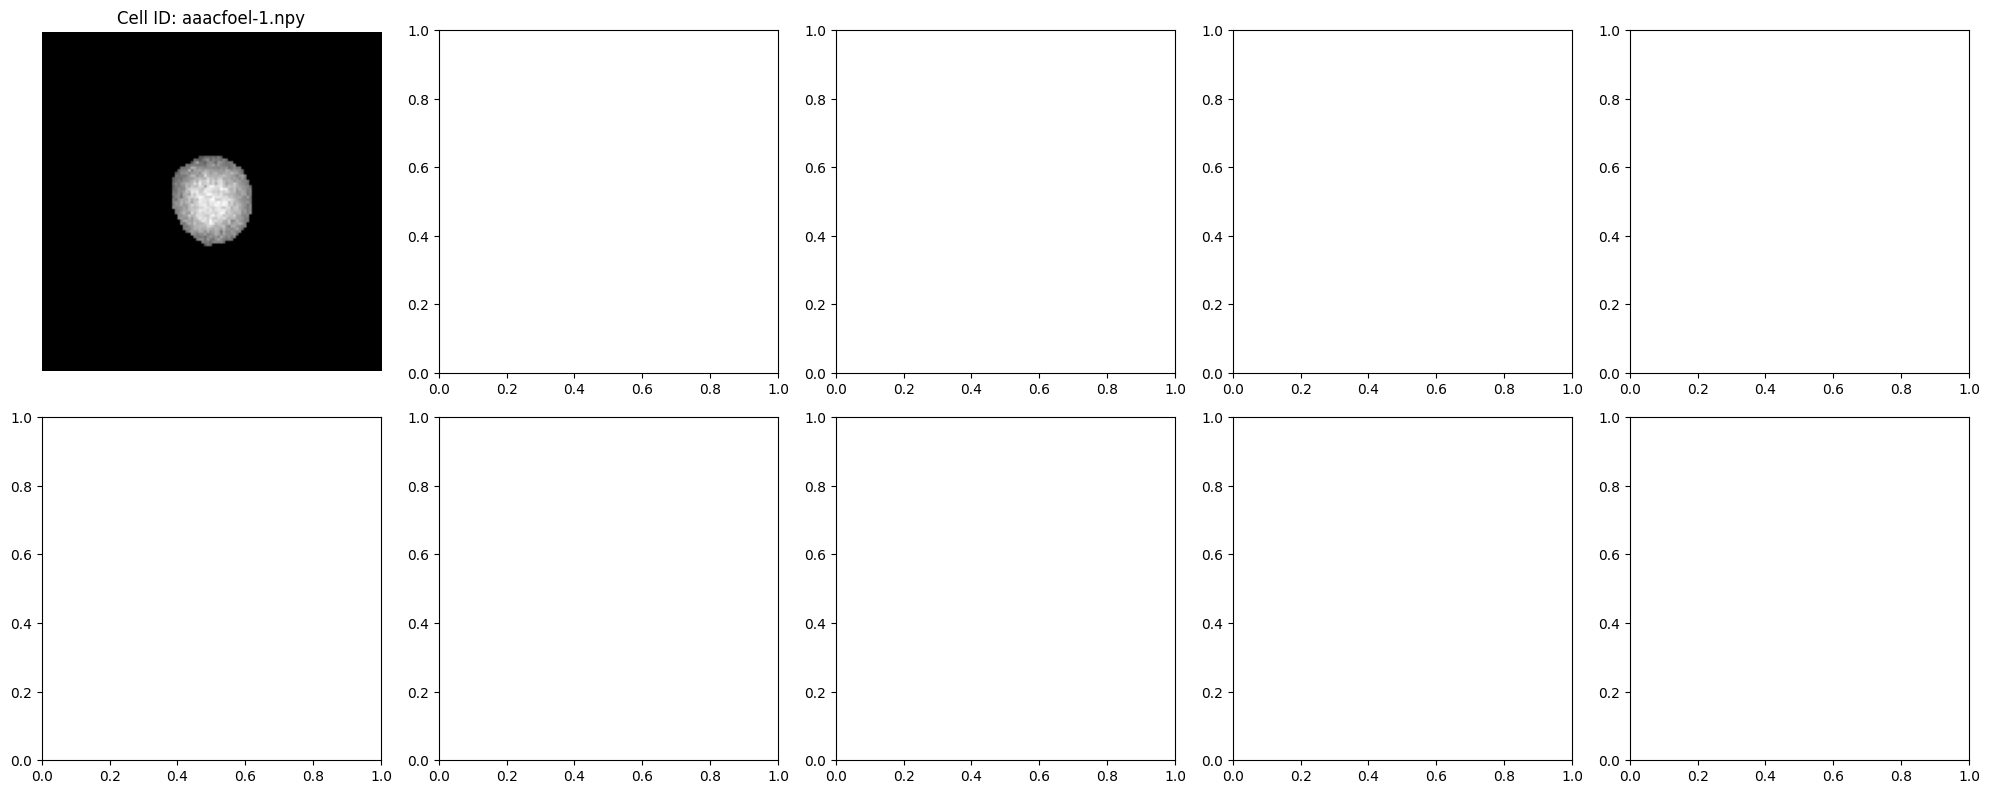

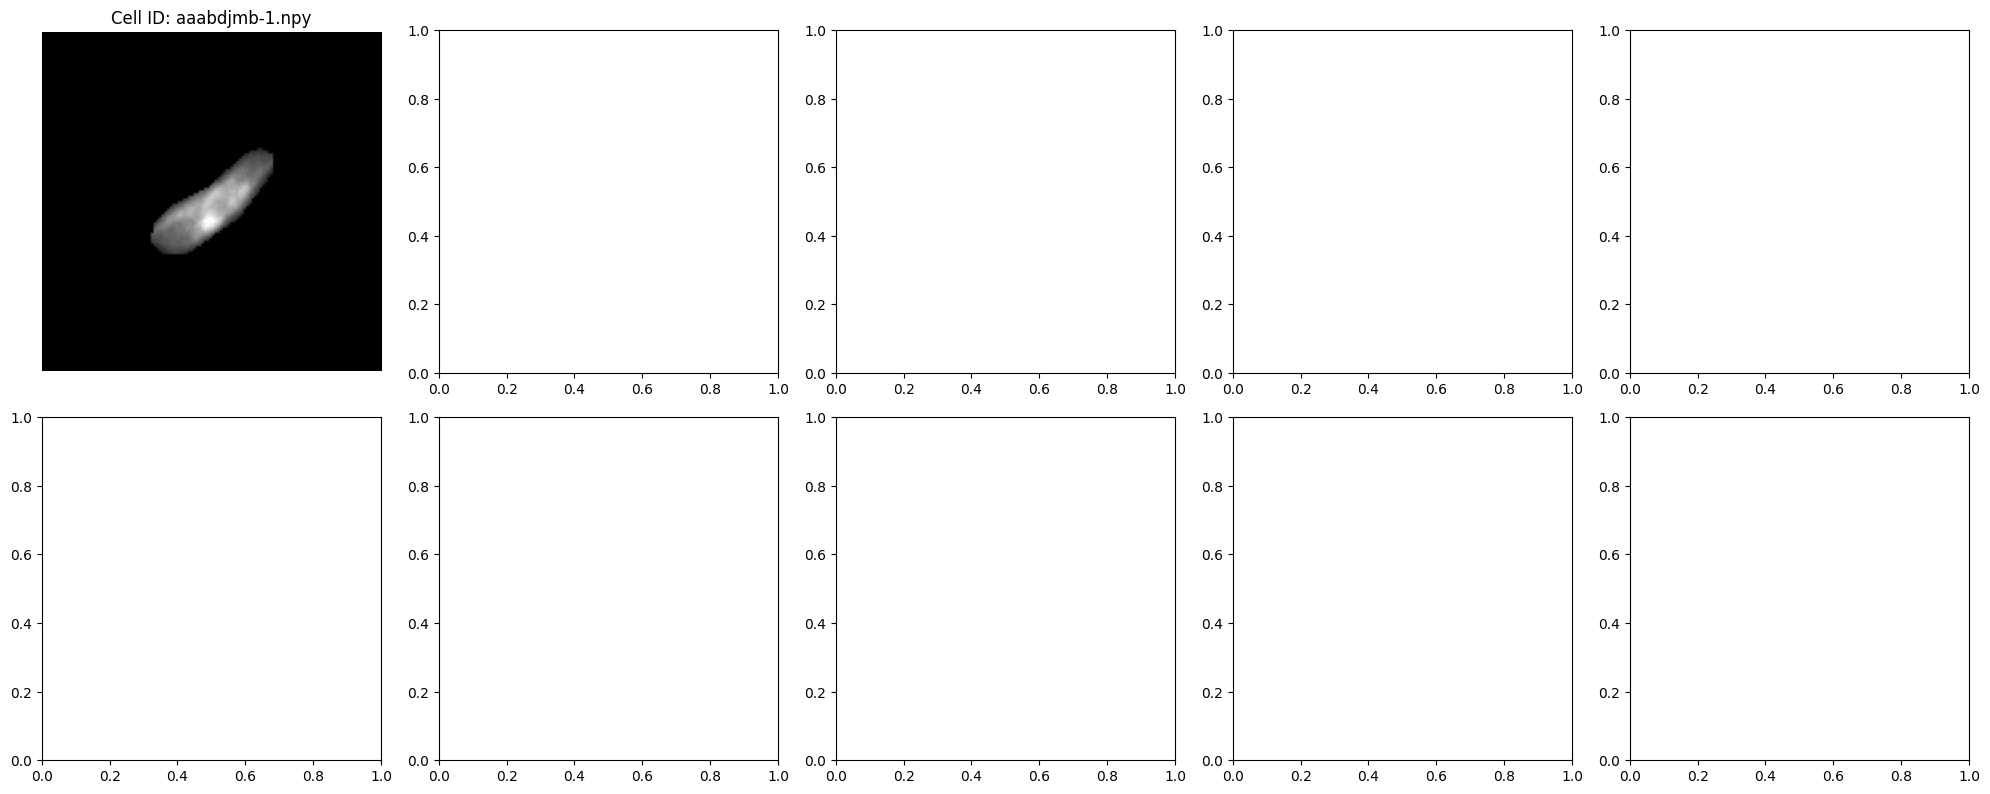

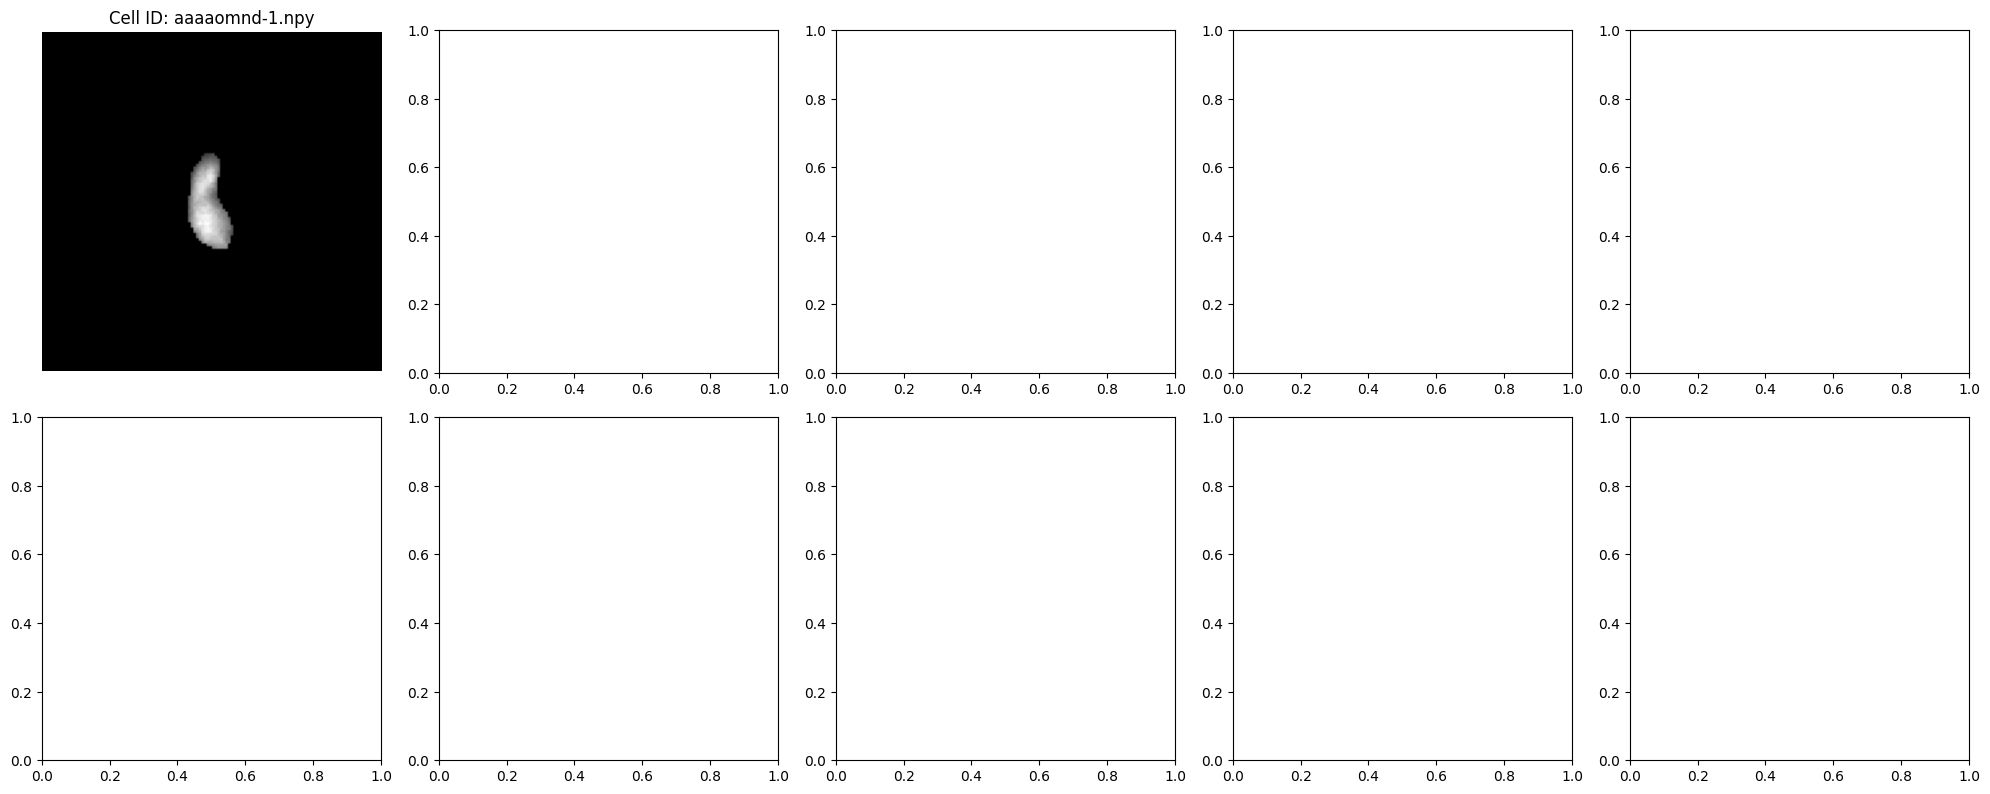

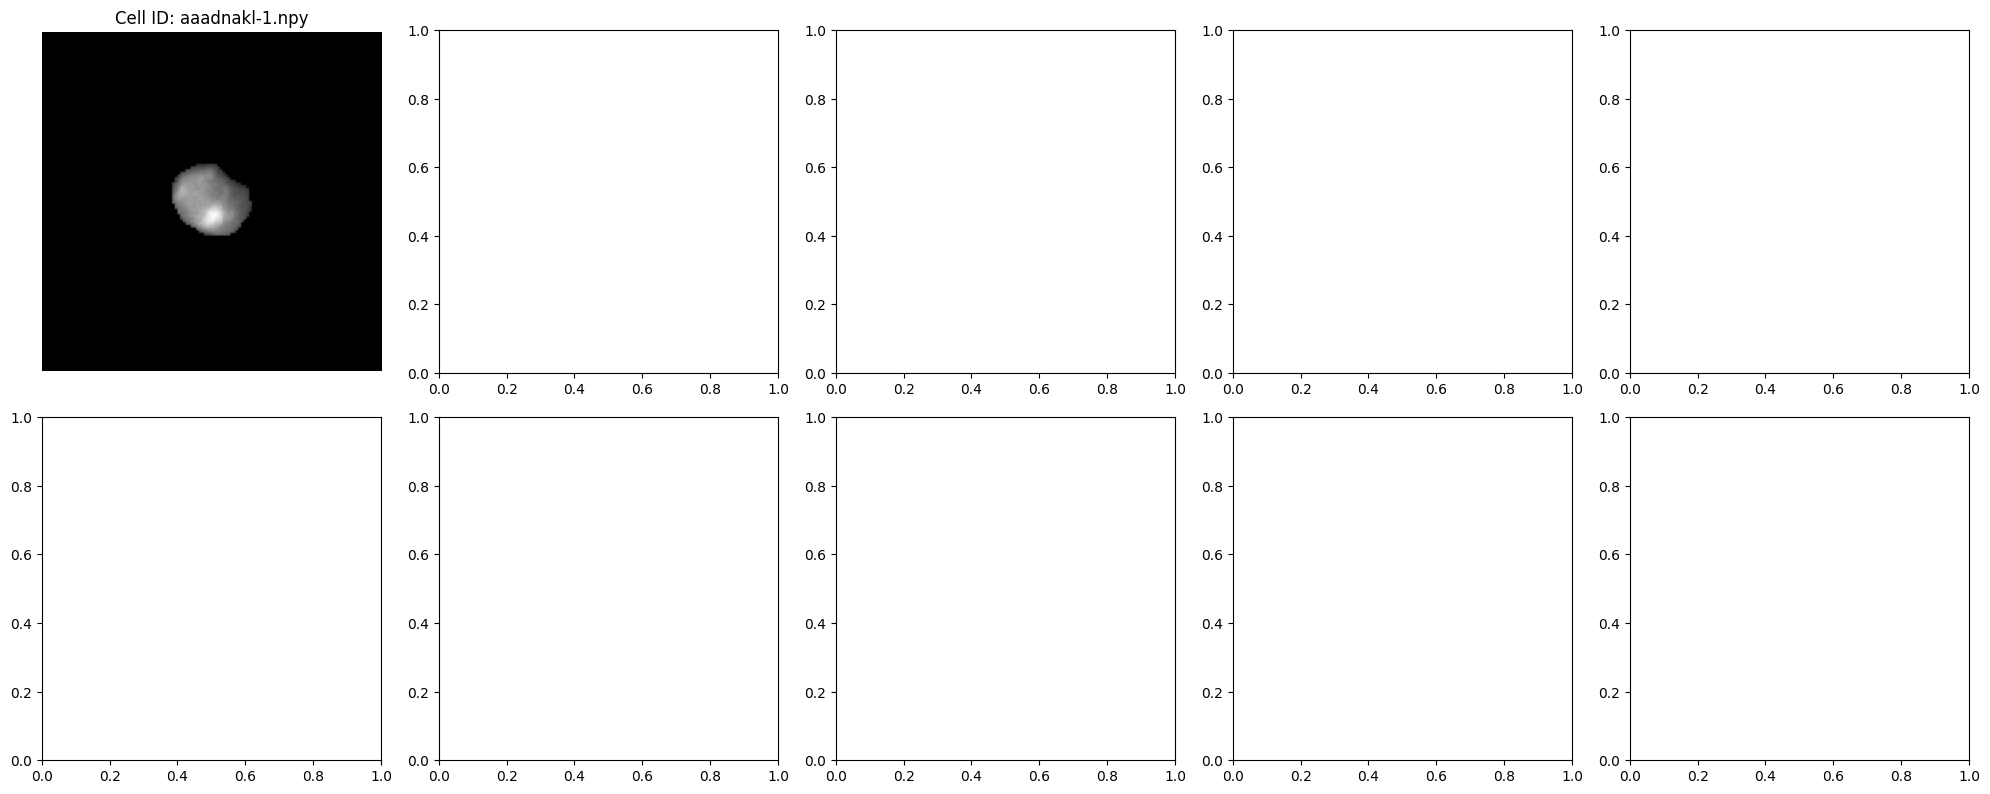

In [10]:
# load the tar file and plot randomly 10 cell images from each sample
import tarfile
import numpy as np
import matplotlib.pyplot as plt
import random
# load the tar file and plot randomly 10 cell images from each sample
output_dir = "/home/anagupta/luna/preprocess/cell_images"
sample_names = [directory.split("_V1_FFPE_")[1].split("_months_outs")[0] for directory in directories]

for sample_name in sample_names:
    tar_file_path = os.path.join(output_dir, f"{sample_name}_cell_images.tar")
    with tarfile.open(tar_file_path, "r") as tar:
        members = tar.getmembers()
        random_members = random.sample(members, 1)
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        for ax, member in zip(axes.flatten(), random_members):
            # Extract the image from the tar file
            img_buffer = tar.extractfile(member).read()
            cell_img = np.load(io.BytesIO(img_buffer))
            ax.imshow(cell_img, cmap="gray")
            ax.set_title(f"Cell ID: {member.name}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()


In [ ]:
# %%
import os
import gc
import h5py
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt

directories = [
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_2_5_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_5_7_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_TgCRND8_17_9_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_2_5_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_5_7_months_outs/",
    "/scratch/anagupta/xenium_data/Xenium_V1_FFPE_wildtype_13_4_months_outs/"
    ]

# read nucleus_boundaries.parquet and morphology_focus.ome.tif for each directory
for directory in directories:
    sample_name = directory.split("_V1_FFPE_")[1].split("_months_outs")[0]

    df = pd.read_parquet(os.path.join(directory, "nucleus_boundaries.parquet"), engine="pyarrow")
    tiff = tifffile.imread(os.path.join(directory, "morphology_focus.ome.tif"), is_ome=False, level=0)
    print(f"Loaded {directory} with shape {tiff.shape} and {df.shape[0]} rows")

    # extract cell coordinates
    cell_boundary_vertices = extract_cell_boundary_vertices(df)
    print("cell_boundary_vertices", cell_boundary_vertices)
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, sample_name + "_cell_images.hdf5")


    for i, (cell_id, cell_boundary_vertices) in enumerate(cell_boundary_vertices.items()):
        if i % 1000 == 0:
            print(f"Processed {i} cell_images...")
        try:
            # Extract the polygon region from the image
            cell_img = extract_cell_image_from_boundary_vertices(tiff, cell_boundary_vertices)
            print(f"Extracted cell image for cell_id {cell_id} with shape {cell_img.shape}")
        except Exception as e:
            print(f"Error processing cell_id {cell_id} in {sample_name}: {e}. Skipping.")
            continue